# Wyniki interwencji `score_control`

Notebook pokazuje kolejno: poprawność wykonania interwencji, zmianę końcowej trafności, porównania sparowane z kontrolami oraz relację między zmianą `score` i marginesu logitowego.

In [1]:
from pathlib import Path
import sys

REPO_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src').is_dir()), Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

from src.analysis.intervention_results import (
    load_all_intervention_runs, outcome_metrics, paired_branch_metrics,
)
from src.analysis.run_discovery import (
    INTERVENTION_LABELS, INTERVENTION_ORDER, MODEL_ORDER, apply_model_order,
)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'font.family': 'DejaVu Sans', 'axes.unicode_minus': False})
pd.set_option('display.max_columns', 60)

In [2]:
runs = load_all_intervention_runs()
all_raw = apply_model_order(pd.concat([run['raw'] for run in runs], ignore_index=True))
accepted = all_raw[all_raw['accepted_intervention']].copy()
print(f'Zaakceptowane obserwacje: {len(accepted):,}; modele: {accepted.model.nunique()}')

Zaakceptowane obserwacje: 36,081; modele: 5


## Kontrola wykonania interwencji

In [3]:
sanity = accepted.groupby(['model', 'intervention_type'], observed=True).agg(
    n=('example_id', 'size'),
    mean_relative_norm=('delta_over_token_hidden_l2', 'mean'),
    mean_score_gain=('score_gain', 'mean'),
    positive_score_change=('score_gain', lambda x: (x > 0).mean()),
).reset_index()
sanity['wariant'] = sanity['intervention_type'].map(INTERVENTION_LABELS)
display(sanity[['model', 'wariant', 'n', 'mean_relative_norm', 'mean_score_gain', 'positive_score_change']].round(4))

,model,wariant,n,mean_relative_norm,mean_score_gain,positive_score_change
0,Qwen 0.5B,ascent,2454,0.0441,1.3008,1.0000
1,Qwen 0.5B,descent,2454,0.0441,0.0330,0.5000
2,Qwen 0.5B,random,2454,0.0441,-0.0014,0.3875
3,Qwen 3B,ascent,1920,0.0379,1.1145,1.0000
4,Qwen 3B,descent,1920,0.0379,-0.6132,0.2521
5,Qwen 3B,random,1920,0.0379,0.0421,0.3859
6,Qwen 7B,ascent,2599,0.0426,0.8307,1.0000
7,Qwen 7B,descent,2599,0.0426,-0.3410,0.3513
8,Qwen 7B,random,2599,0.0426,-0.0058,0.3755
9,Llama 1B,ascent,2486,0.0422,1.0717,1.0000


## Wpływ na końcową odpowiedź

,model,wariant,n,clean_accuracy,steered_accuracy,delta_accuracy,rescue_rate,harm_rate,mean_score_gain,mean_margin_change
0,Qwen 0.5B,ascent,2454,0.5416,0.5204,-0.0212,0.0236,0.0448,1.3008,-0.5863
1,Qwen 0.5B,descent,2454,0.5416,0.4128,-0.1288,0.1023,0.2311,0.0330,-2.1141
2,Qwen 0.5B,random,2454,0.5416,0.5342,-0.0073,0.0167,0.0240,-0.0014,-0.0216
3,Qwen 3B,ascent,1920,0.7089,0.7062,-0.0026,0.0292,0.0318,1.1145,0.7943
4,Qwen 3B,descent,1920,0.7089,0.7036,-0.0052,0.0474,0.0526,-0.6132,-1.4730
5,Qwen 3B,random,1920,0.7089,0.7042,-0.0047,0.0000,0.0047,0.0421,-0.0553
6,Qwen 7B,ascent,2599,0.8461,0.8095,-0.0366,0.0265,0.0631,0.8307,1.4204
7,Qwen 7B,descent,2599,0.8461,0.6837,-0.1624,0.0473,0.2097,-0.3410,-2.3154
8,Qwen 7B,random,2599,0.8461,0.8465,0.0004,0.0123,0.0119,-0.0058,0.0129
9,Llama 1B,ascent,2486,0.4722,0.4747,0.0024,0.0221,0.0197,1.0717,-0.5662


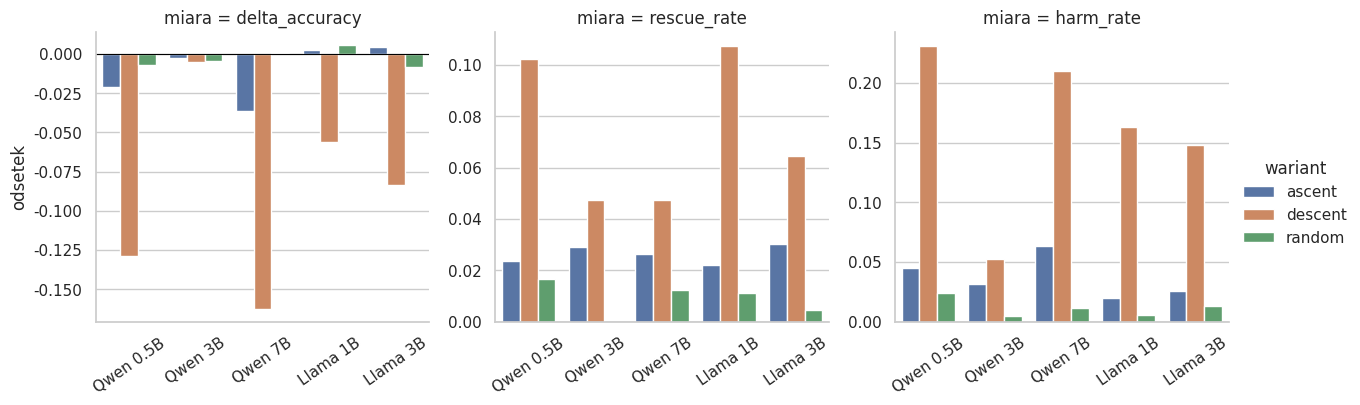

In [4]:
overall = outcome_metrics(accepted, ['model', 'intervention_type'])
overall['wariant'] = overall['intervention_type'].map(INTERVENTION_LABELS)
display(overall[[
    'model', 'wariant', 'n', 'clean_accuracy', 'steered_accuracy',
    'delta_accuracy', 'rescue_rate', 'harm_rate', 'mean_score_gain', 'mean_margin_change',
]].round(4))

plot_data = overall.melt(
    id_vars=['model', 'wariant'],
    value_vars=['delta_accuracy', 'rescue_rate', 'harm_rate'],
    var_name='miara', value_name='wartość',
)
g = sns.catplot(
    data=plot_data, x='model', y='wartość', hue='wariant',
    col='miara', kind='bar', height=4, aspect=1.05, sharey=False,
)
g.set_axis_labels('', 'odsetek')
for ax in g.axes.flat:
    ax.axhline(0, color='black', lw=0.8)
    ax.tick_params(axis='x', rotation=35)

## Porównania sparowane z kontrolami

c:\Users\mikol\OneDrive\Pulpit\Praca Magisterska\Transformer-Decision-Traces\src\analysis\intervention_results.py:160: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = frame.pivot_table(


,model,matched_triplets,ascent_minus_random_accuracy,ascent_minus_descent_accuracy,ascent_vs_random_harm_reduction,ascent_vs_descent_harm_reduction
0,Qwen 0.5B,2454,-0.0139,0.1076,-0.0208,0.1862
1,Qwen 3B,1920,0.0021,0.0026,-0.0271,0.0208
2,Qwen 7B,2599,-0.0369,0.1258,-0.0512,0.1466
3,Llama 1B,2486,-0.0032,0.0583,-0.0141,0.1436
4,Llama 3B,2568,0.0132,0.0880,-0.0125,0.1223


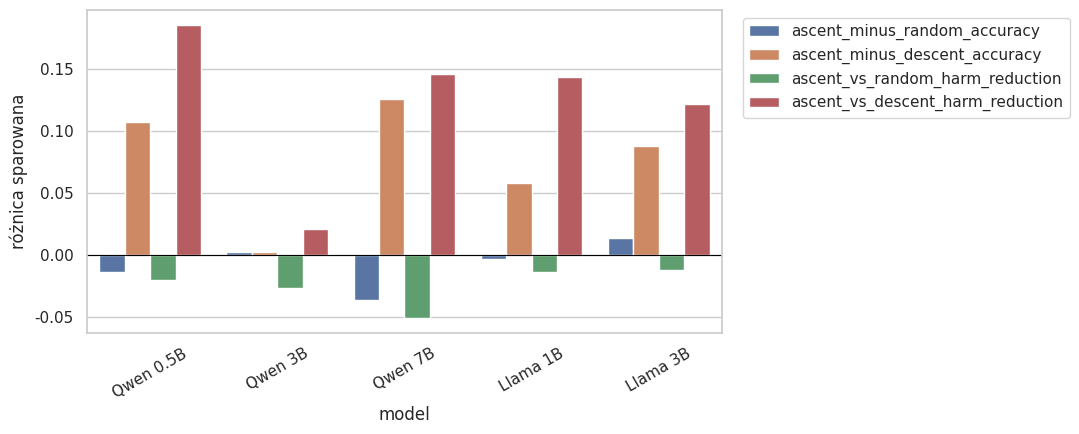

In [5]:
paired = paired_branch_metrics(accepted, ['model'])
display(paired.round(4))

paired_long = paired.melt(
    id_vars=['model'],
    value_vars=[
        'ascent_minus_random_accuracy', 'ascent_minus_descent_accuracy',
        'ascent_vs_random_harm_reduction', 'ascent_vs_descent_harm_reduction',
    ],
    var_name='porównanie', value_name='przewaga_ascent',
)
plt.figure(figsize=(11, 4.5))
sns.barplot(data=paired_long, x='model', y='przewaga_ascent', hue='porównanie')
plt.axhline(0, color='black', lw=0.8)
plt.ylabel('różnica sparowana')
plt.xticks(rotation=30)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

## Wyniki według cechy

In [6]:
by_feature = outcome_metrics(accepted, ['model', 'feature', 'intervention_type'])
by_feature['wariant'] = by_feature['intervention_type'].map(INTERVENTION_LABELS)
display(by_feature[[
    'model', 'feature', 'wariant', 'delta_accuracy', 'rescue_rate',
    'harm_rate', 'mean_score_gain', 'mean_margin_change',
]].round(4))

,model,feature,wariant,delta_accuracy,rescue_rate,harm_rate,mean_score_gain,mean_margin_change
0,Qwen 0.5B,entropia odpowiedzi,ascent,-0.0065,0.0237,0.0301,1.2563,-0.1911
1,Qwen 0.5B,entropia odpowiedzi,descent,-0.1667,0.1000,0.2667,-0.3207,-2.0881
2,Qwen 0.5B,entropia odpowiedzi,random,-0.0075,0.0183,0.0258,-0.0007,-0.0144
3,Qwen 0.5B,luka logitów top-1/top-2,ascent,-0.0213,0.0203,0.0416,1.8700,-0.4666
4,Qwen 0.5B,luka logitów top-1/top-2,descent,-0.1366,0.1153,0.2519,0.3759,-2.7358
5,Qwen 0.5B,luka logitów top-1/top-2,random,-0.0064,0.0139,0.0203,-0.0039,-0.0276
6,Qwen 0.5B,varentropy odpowiedzi,ascent,-0.0443,0.0290,0.0733,0.4630,-1.4034
7,Qwen 0.5B,varentropy odpowiedzi,descent,-0.0562,0.0852,0.1414,0.0387,-1.1628
8,Qwen 0.5B,varentropy odpowiedzi,random,-0.0085,0.0187,0.0273,0.0013,-0.0232
9,Qwen 3B,entropia odpowiedzi,ascent,0.0033,0.0294,0.0261,1.0750,0.8195


## Zmiana `score` a zmiana marginesu logitowego

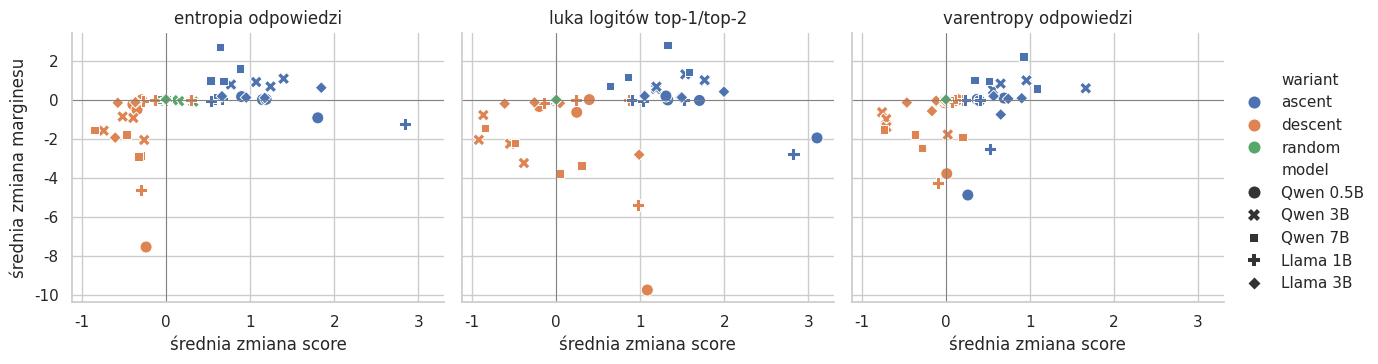

In [7]:
cells = accepted.groupby(
    ['model', 'feature', 'layer_number', 'intervention_type'], observed=True
).agg(
    mean_score_gain=('score_gain', 'mean'),
    mean_margin_change=('correct_vs_best_wrong_gap_change', 'mean'),
    delta_accuracy=('accuracy_delta', 'mean'),
).reset_index()
cells['wariant'] = cells['intervention_type'].map(INTERVENTION_LABELS)

g = sns.relplot(
    data=cells, x='mean_score_gain', y='mean_margin_change',
    hue='wariant', style='model', col='feature', col_wrap=3,
    height=3.8, aspect=1.1, s=75,
)
g.set_axis_labels('średnia zmiana score', 'średnia zmiana marginesu')
g.set_titles('{col_name}')
for ax in g.axes.flat:
    ax.axhline(0, color='grey', lw=0.7)
    ax.axvline(0, color='grey', lw=0.7)